# Transformer Attention Mechanisms: A Practical Tutorial

**Author:** Titiloye Dolapo Michael 
**Course:** Machine Learning 
**GitHub Repository:** https://github.com/DolapoMichael/transformer-attention-tutorial

---

## Overview

This tutorial walks through **Transformer attention mechanisms** from first principles, building up to a working multi-head attention implementation and sentiment classifier on IMDB movie reviews.

### What you will learn:
1. Why attention was needed (the problem with RNNs)
2. Scaled Dot-Product Attention — the math and the code
3. Multi-Head Attention — why multiple heads?
4. Visualising attention weights on real text
5. Single-head vs multi-head performance comparison

### Key Reference:
> Vaswani, A. et al. (2017). **Attention is all you need.** *NeurIPS*. https://arxiv.org/abs/1706.03762


---
## Cell 1 — Install packages


In [12]:
import sys
!{sys.executable} -m pip install numpy matplotlib seaborn scikit-learn datasets --quiet
print('All packages installed!')

All packages installed!


---
## Cell 2 — Imports

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from datasets import load_dataset
from collections import Counter
import re
import math
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)
print('All imports successful!')

All imports successful!


---
## 1. Motivation: Why Attention?

Before transformers, **RNNs and LSTMs** processed text token by token, left to right. Two key problems:

1. **Long-range forgetting** — information from early tokens is overwritten by the time the model reaches later ones.
2. **Sequential bottleneck** — each step depends on the last, preventing parallelisation.

**Attention** solves both: every token attends directly to every other in one parallel step.

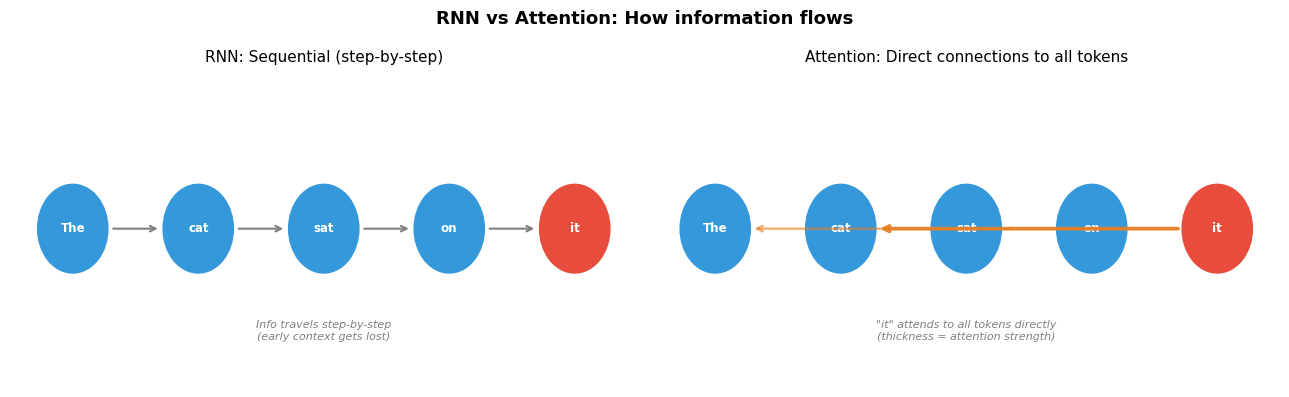

Figure 1 saved.


In [14]:
# Figure 1: RNN vs Attention
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle('RNN vs Attention: How information flows', fontsize=13, fontweight='bold')

words = ['The', 'cat', 'sat', 'on', 'it']
n = len(words)

ax1 = axes[0]
ax1.set_title('RNN: Sequential (step-by-step)', fontsize=11)
ax1.set_xlim(-0.5, n - 0.5)
ax1.set_ylim(0, 2)
ax1.axis('off')
for i, word in enumerate(words):
    col = '#e74c3c' if word == 'it' else '#3498db'
    ax1.add_patch(plt.Circle((i, 1), 0.28, color=col, zorder=3))
    ax1.text(i, 1, word, ha='center', va='center', fontsize=8.5, color='white', fontweight='bold')
    if i > 0:
        ax1.annotate('', xy=(i - 0.3, 1), xytext=(i - 0.7, 1),
                     arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
ax1.text(2, 0.3, 'Info travels step-by-step\n(early context gets lost)',
         ha='center', fontsize=8, color='gray', style='italic')

ax2 = axes[1]
ax2.set_title('Attention: Direct connections to all tokens', fontsize=11)
ax2.set_xlim(-0.5, n - 0.5)
ax2.set_ylim(0, 2)
ax2.axis('off')
attn_w = [0.6, 0.9, 0.2, 0.1]
for i, word in enumerate(words):
    col = '#e74c3c' if word == 'it' else '#3498db'
    ax2.add_patch(plt.Circle((i, 1), 0.28, color=col, zorder=3))
    ax2.text(i, 1, word, ha='center', va='center', fontsize=8.5, color='white', fontweight='bold')
for i in range(n - 1):
    a = attn_w[i]
    ax2.annotate('', xy=(i + 0.29, 1), xytext=(n - 1 - 0.29, 1),
                 arrowprops=dict(arrowstyle='->', color='#e67e22', lw=a * 3, alpha=a))
ax2.text(2, 0.3, '"it" attends to all tokens directly\n(thickness = attention strength)',
         ha='center', fontsize=8, color='gray', style='italic')

plt.tight_layout()
plt.savefig('fig1_rnn_vs_attention.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figure 1 saved.')

---
## 2. Scaled Dot-Product Attention

The attention formula from Vaswani et al. (2017):

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

- **Q** (Query): what am I looking for?
- **K** (Key): what does each token offer?
- **V** (Value): what information do I return?
- **sqrt(d_k)** scaling: prevents large dot products from pushing softmax into near-zero gradient regions.

In [15]:
def softmax(x, axis=-1):
    """Numerically stable softmax"""
    e = np.exp(x - np.max(x, axis=axis, keepdims=True))
    return e / e.sum(axis=axis, keepdims=True)

def scaled_dot_product_attention(Q, K, V):
    """
    Scaled Dot-Product Attention (Vaswani et al., 2017)

    Args:
        Q: Query  (seq_len, d_k)
        K: Key    (seq_len, d_k)
        V: Value  (seq_len, d_v)
    Returns:
        output:           (seq_len, d_v)
        attention_weights: (seq_len, seq_len)
    """
    d_k = Q.shape[-1]
    scores = Q @ K.T                       # raw similarity scores
    scores = scores / math.sqrt(d_k)       # scale
    attention_weights = softmax(scores)    # softmax -> weights summing to 1
    output = attention_weights @ V         # weighted sum of values
    return output, attention_weights


# Toy walkthrough
seq_len, d_k, d_v = 5, 8, 8
np.random.seed(0)
Q = np.random.randn(seq_len, d_k)
K = np.random.randn(seq_len, d_k)
V = np.random.randn(seq_len, d_v)

output, attn_weights = scaled_dot_product_attention(Q, K, V)

print('=== Scaled Dot-Product Attention — Toy Example ===')
print(f'Q, K, V shape:        {Q.shape}')
print(f'Attention weights:    {attn_weights.shape}  (each row sums to 1)')
print(f'Output shape:         {output.shape}')
print(f'Row 0 weights:        {attn_weights[0].round(3)}')
print(f'Row 0 sum:            {attn_weights[0].sum():.4f}')

=== Scaled Dot-Product Attention — Toy Example ===
Q, K, V shape:        (5, 8)
Attention weights:    (5, 5)  (each row sums to 1)
Output shape:         (5, 8)
Row 0 weights:        [0.219 0.139 0.15  0.225 0.267]
Row 0 sum:            1.0000


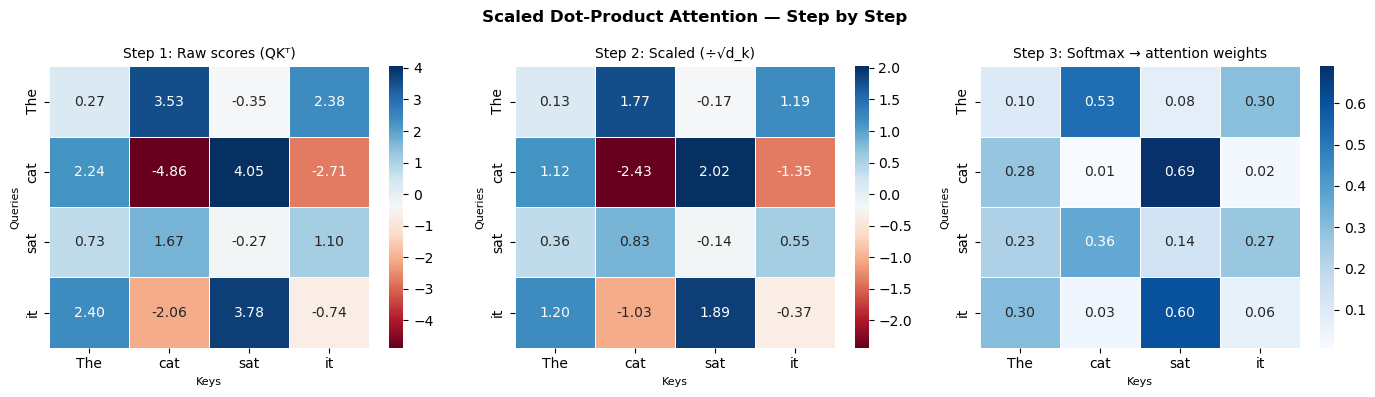

Figure 2 saved.


In [16]:
# Figure 2: Step-by-step attention heatmaps
tokens = ['The', 'cat', 'sat', 'it']
n = len(tokens)
np.random.seed(7)
Qs = np.random.randn(n, 4)
Ks = np.random.randn(n, 4)
Vs = np.random.randn(n, 4)

raw    = Qs @ Ks.T
scaled = raw / math.sqrt(4)
attn_w = softmax(scaled)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle('Scaled Dot-Product Attention — Step by Step', fontsize=12, fontweight='bold')

for ax, mat, title, cmap in zip(
    axes,
    [raw, scaled, attn_w],
    ['Step 1: Raw scores (QKᵀ)', 'Step 2: Scaled (÷√d_k)', 'Step 3: Softmax → attention weights'],
    ['RdBu', 'RdBu', 'Blues']
):
    sns.heatmap(mat, ax=ax, xticklabels=tokens, yticklabels=tokens,
                annot=True, fmt='.2f', cmap=cmap, linewidths=0.5)
    ax.set_title(title, fontsize=10)
    ax.set_xlabel('Keys', fontsize=8)
    ax.set_ylabel('Queries', fontsize=8)

plt.tight_layout()
plt.savefig('fig2_attention_steps.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figure 2 saved.')

---
## 3. Multi-Head Attention

A single head can only learn **one relational pattern** at a time. Multi-head attention runs **h heads in parallel**, each with its own projections:

$$\text{MultiHead}(Q,K,V) = \text{Concat}(\text{head}_1,...,\text{head}_h)W^O$$

Each head works in a reduced dimension $d_k = d_{\text{model}} / h$ — so total compute stays the same, but representational power increases.

In [17]:
class MultiHeadAttention:
    """
    Multi-Head Self-Attention (Vaswani et al., 2017) in pure NumPy.
    """
    def __init__(self, d_model, num_heads, seed=0):
        assert d_model % num_heads == 0
        self.d_model   = d_model
        self.num_heads = num_heads
        self.d_k       = d_model // num_heads
        rng = np.random.default_rng(seed)
        s = 0.1
        self.Wq = [rng.normal(0, s, (d_model, self.d_k)) for _ in range(num_heads)]
        self.Wk = [rng.normal(0, s, (d_model, self.d_k)) for _ in range(num_heads)]
        self.Wv = [rng.normal(0, s, (d_model, self.d_k)) for _ in range(num_heads)]
        self.Wo = rng.normal(0, s, (d_model, d_model))

    def forward(self, X):
        """
        X: (seq_len, d_model)
        Returns output (seq_len, d_model) and list of attention weight matrices.
        """
        head_outputs, all_weights = [], []
        for i in range(self.num_heads):
            Q = X @ self.Wq[i]
            K = X @ self.Wk[i]
            V = X @ self.Wv[i]
            out, w = scaled_dot_product_attention(Q, K, V)
            head_outputs.append(out)
            all_weights.append(w)
        concat = np.concatenate(head_outputs, axis=-1)
        return concat @ self.Wo, all_weights


# Test
mha = MultiHeadAttention(d_model=64, num_heads=4)
X   = np.random.randn(6, 64)
out, weights = mha.forward(X)
print(f'Input shape:  {X.shape}')
print(f'Output shape: {out.shape}  (same as input)')
print(f'Heads:        {len(weights)}, each weight matrix: {weights[0].shape}')

Input shape:  (6, 64)
Output shape: (6, 64)  (same as input)
Heads:        4, each weight matrix: (6, 6)


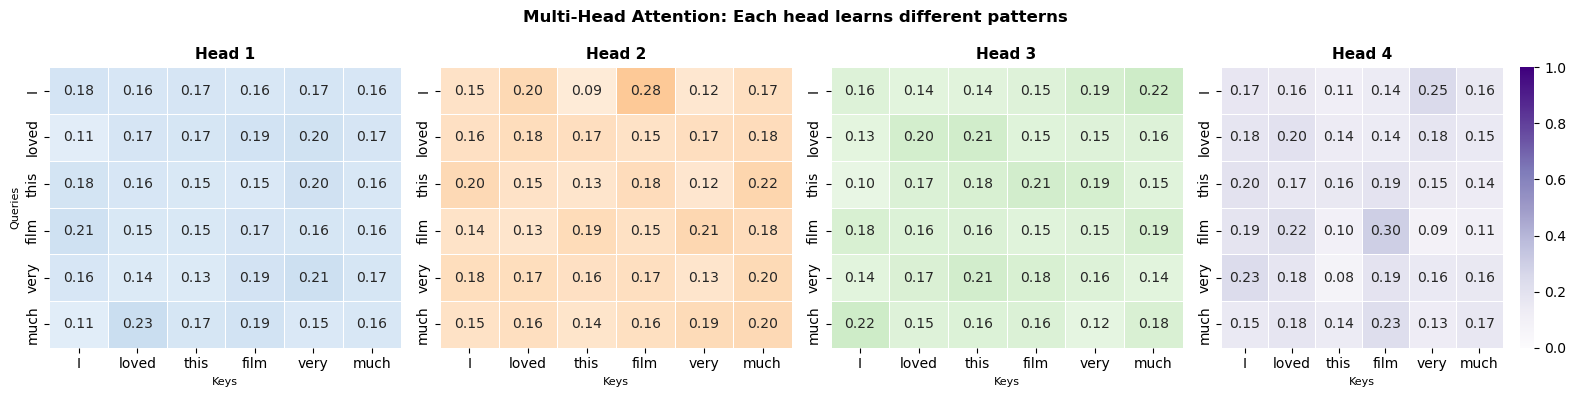

Figure 3 saved.


In [18]:
# Figure 3: Each head attends differently
tokens_6 = ['I', 'loved', 'this', 'film', 'very', 'much']
mha_vis  = MultiHeadAttention(d_model=32, num_heads=4, seed=21)
X_vis    = np.random.randn(len(tokens_6), 32)
_, w_vis = mha_vis.forward(X_vis)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
fig.suptitle('Multi-Head Attention: Each head learns different patterns', fontsize=12, fontweight='bold')

for i, ax in enumerate(axes):
    sns.heatmap(w_vis[i], ax=ax, xticklabels=tokens_6, yticklabels=tokens_6,
                annot=True, fmt='.2f', cmap=['Blues','Oranges','Greens','Purples'][i],
                linewidths=0.5, vmin=0, vmax=1, cbar=(i == 3))
    ax.set_title(f'Head {i+1}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Keys', fontsize=8)
    ax.set_ylabel('Queries' if i == 0 else '', fontsize=8)

plt.tight_layout()
plt.savefig('fig3_multihead_attention.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figure 3 saved.')

---
## 4. Positional Encoding

Attention is **permutation-invariant** — shuffling words gives the same scores. Positional encodings fix this by adding position information using sine and cosine functions:

$$PE_{(pos,\ 2i)} = \sin\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right), \quad PE_{(pos,\ 2i+1)} = \cos\left(\frac{pos}{10000^{2i/d_{\text{model}}}}\right)$$

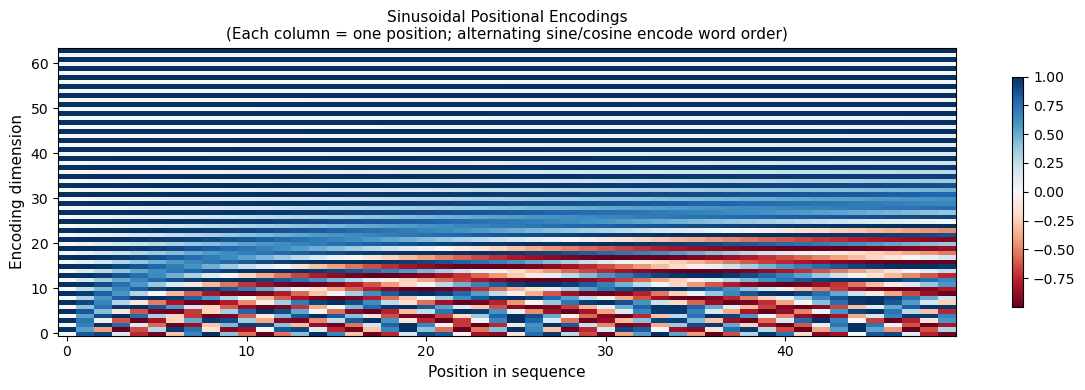

Figure 4 saved.


In [19]:
def positional_encoding(max_len, d_model):
    """Sinusoidal positional encoding (Vaswani et al., 2017)"""
    pe  = np.zeros((max_len, d_model))
    pos = np.arange(max_len)[:, None]
    div = np.exp(np.arange(0, d_model, 2) * (-math.log(10000.0) / d_model))
    pe[:, 0::2] = np.sin(pos * div)
    pe[:, 1::2] = np.cos(pos * div)
    return pe

pe = positional_encoding(50, 64)

fig, ax = plt.subplots(figsize=(12, 4))
im = ax.imshow(pe.T, aspect='auto', cmap='RdBu', origin='lower')
ax.set_xlabel('Position in sequence', fontsize=11)
ax.set_ylabel('Encoding dimension',   fontsize=11)
ax.set_title('Sinusoidal Positional Encodings\n(Each column = one position; alternating sine/cosine encode word order)', fontsize=11)
plt.colorbar(im, ax=ax, shrink=0.8)
plt.tight_layout()
plt.savefig('fig4_positional_encoding.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figure 4 saved.')

---
## 5. Demo: Sentiment Analysis on IMDB

We apply attention to **IMDB sentiment classification**.

Pipeline:
1. Load IMDB reviews
2. Embed words → add positional encoding → apply multi-head attention
3. Mean-pool the attended output → logistic regression classifier
4. Compare 1-head vs 4-head vs 8-head

In [20]:
print('Loading IMDB...')
ds = load_dataset('imdb')

# Shuffle BEFORE slicing — the raw IMDB dataset is sorted by label,
# so slicing [:N] without shuffling gives only one class.
import random
random.seed(42)

N_TRAIN, N_TEST = 2000, 500

train_all = list(zip(ds['train']['text'], ds['train']['label']))
test_all  = list(zip(ds['test']['text'],  ds['test']['label']))
random.shuffle(train_all)
random.shuffle(test_all)

train_texts,  train_labels = zip(*train_all[:N_TRAIN])
test_texts,   test_labels  = zip(*test_all[:N_TEST])
train_labels = list(train_labels)
test_labels  = list(test_labels)

pos = sum(train_labels)
print(f'Train: {N_TRAIN} ({pos} positive, {N_TRAIN - pos} negative)')
print(f'Test:  {N_TEST}')
print(f'Sample: {train_texts[0][:150]}...')
print(f'Label:  {"positive" if train_labels[0] == 1 else "negative"}')

Loading IMDB...
Train: 2000 (994 positive, 1006 negative)
Test:  500
Sample: Eric Clapton, Jack Bruce and Ginger Baker re-unite to play all their songs from 35 years ago when they formed a trio called "Cream." Those were the ps...
Label:  positive


In [21]:
MAX_SEQ    = 40
VOCAB_SIZE = 3000
D_MODEL    = 32

def tokenise(text):
    text = re.sub(r'<[^>]+>', ' ', text.lower())
    text = re.sub(r'[^a-z\s]', ' ', text)
    return text.split()

counter = Counter()
for t in train_texts:
    counter.update(tokenise(t))

vocab = {'<pad>': 0, '<unk>': 1}
for w, _ in counter.most_common(VOCAB_SIZE - 2):
    vocab[w] = len(vocab)

np.random.seed(42)
EMBEDDINGS = np.random.randn(len(vocab), D_MODEL) * 0.1

print(f'Vocabulary size: {len(vocab):,}')

Vocabulary size: 3,000


In [22]:
def review_to_sequence(text):
    tokens = tokenise(text)[:MAX_SEQ]
    ids    = [vocab.get(t, 1) for t in tokens]
    seq    = np.array([EMBEDDINGS[i] for i in ids])
    seq    = seq + positional_encoding(len(seq), D_MODEL)
    return seq

def extract_features(texts, mha_model):
    features = []
    for text in texts:
        seq = review_to_sequence(text)
        attended, _ = mha_model.forward(seq)
        features.append(attended.mean(axis=0))
    return np.array(features)


results = {}
for h in [1, 2, 4, 8]:
    print(f'Testing {h} head(s)...', end=' ')
    mha = MultiHeadAttention(d_model=D_MODEL, num_heads=h, seed=42)
    X_train = extract_features(train_texts, mha)
    X_test  = extract_features(test_texts,  mha)
    clf = LogisticRegression(max_iter=500, random_state=42)
    clf.fit(X_train, train_labels)
    acc = accuracy_score(test_labels, clf.predict(X_test))
    results[h] = acc
    print(f'accuracy = {acc:.3f}')

print('Done!')

Testing 1 head(s)... accuracy = 0.518
accuracy = 0.532)... 
accuracy = 0.536)... 
accuracy = 0.518)... 
Done!


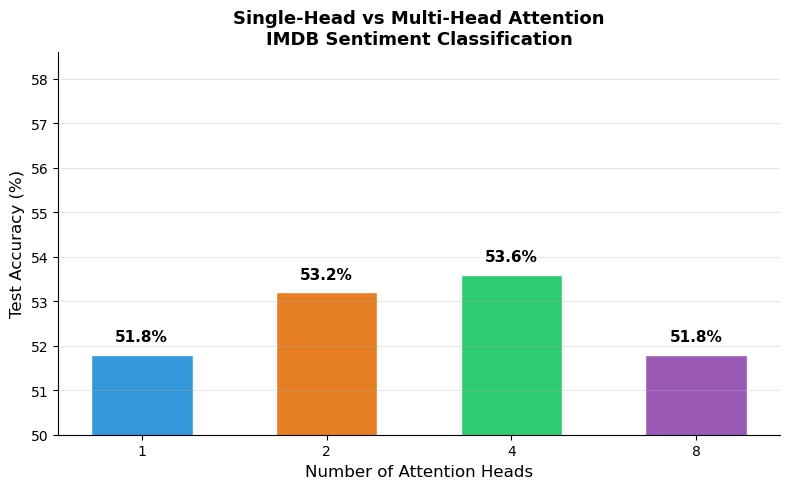

Figure 5 saved.


In [23]:
# Figure 5: Head count comparison
fig, ax = plt.subplots(figsize=(8, 5))
heads  = list(results.keys())
accs   = [results[h] * 100 for h in heads]
colors = ['#3498db', '#e67e22', '#2ecc71', '#9b59b6']

bars = ax.bar([str(h) for h in heads], accs, color=colors, edgecolor='white', width=0.55)
for bar, acc in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{acc:.1f}%', ha='center', fontsize=11, fontweight='bold')

ax.set_xlabel('Number of Attention Heads', fontsize=12)
ax.set_ylabel('Test Accuracy (%)',         fontsize=12)
ax.set_title('Single-Head vs Multi-Head Attention\nIMDB Sentiment Classification',
             fontsize=13, fontweight='bold')
ax.set_ylim(50, max(accs) + 5)
ax.grid(axis='y', alpha=0.3)
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.savefig('fig5_head_comparison.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figure 5 saved.')

---
## 6. Visualising What the Model Attends To

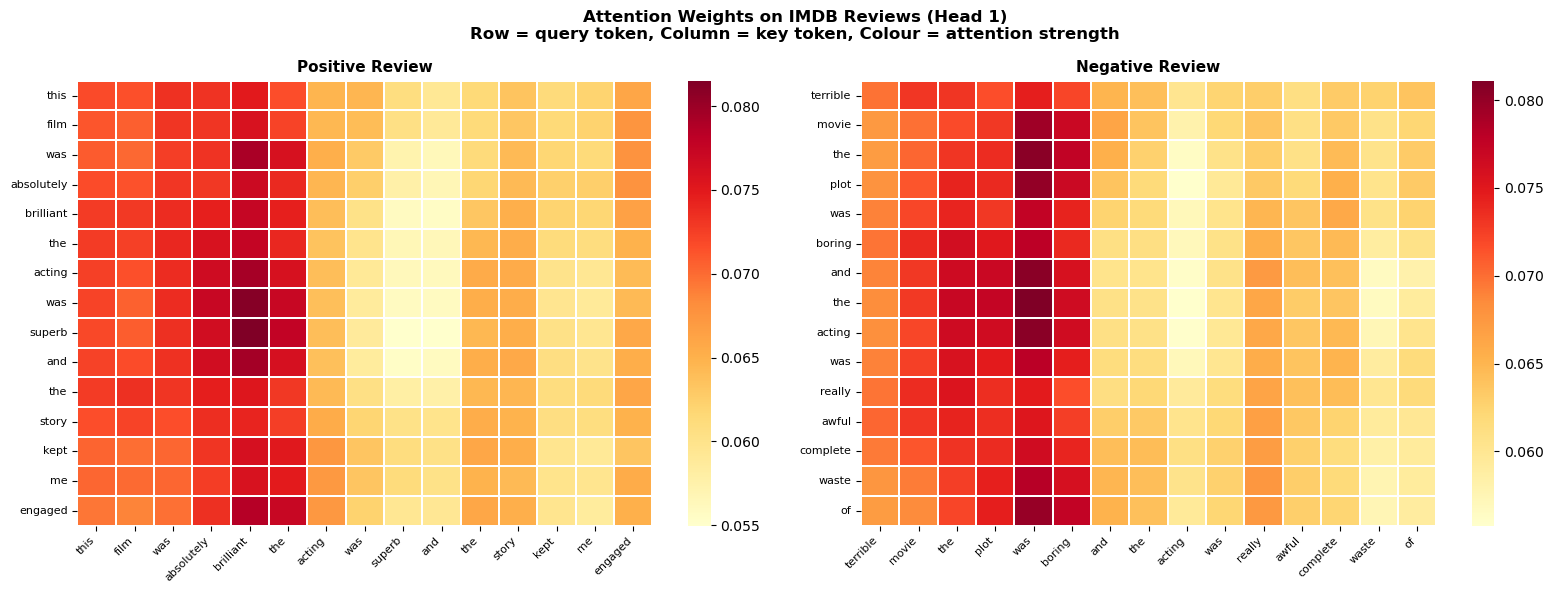

Figure 6 saved.


In [24]:
# Figure 6: Attention heatmaps on real reviews
mha_vis4 = MultiHeadAttention(d_model=D_MODEL, num_heads=4, seed=42)

reviews = [
    ("This film was absolutely brilliant. The acting was superb and the story kept me engaged.",
     'Positive Review'),
    ("Terrible movie. The plot was boring and the acting was really awful. Complete waste of time.",
     'Negative Review'),
]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle('Attention Weights on IMDB Reviews (Head 1)\n'
             'Row = query token, Column = key token, Colour = attention strength',
             fontsize=12, fontweight='bold')

for ax, (text, title) in zip(axes, reviews):
    tokens = tokenise(text)[:15]
    seq    = review_to_sequence(text)[:len(tokens)]
    _, attn = mha_vis4.forward(seq)
    w = attn[0][:len(tokens), :len(tokens)]
    sns.heatmap(w, ax=ax, xticklabels=tokens, yticklabels=tokens,
                cmap='YlOrRd', linewidths=0.3)
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=8)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0,  fontsize=8)
    ax.set_title(title, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.savefig('fig6_attention_on_reviews.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figure 6 saved.')

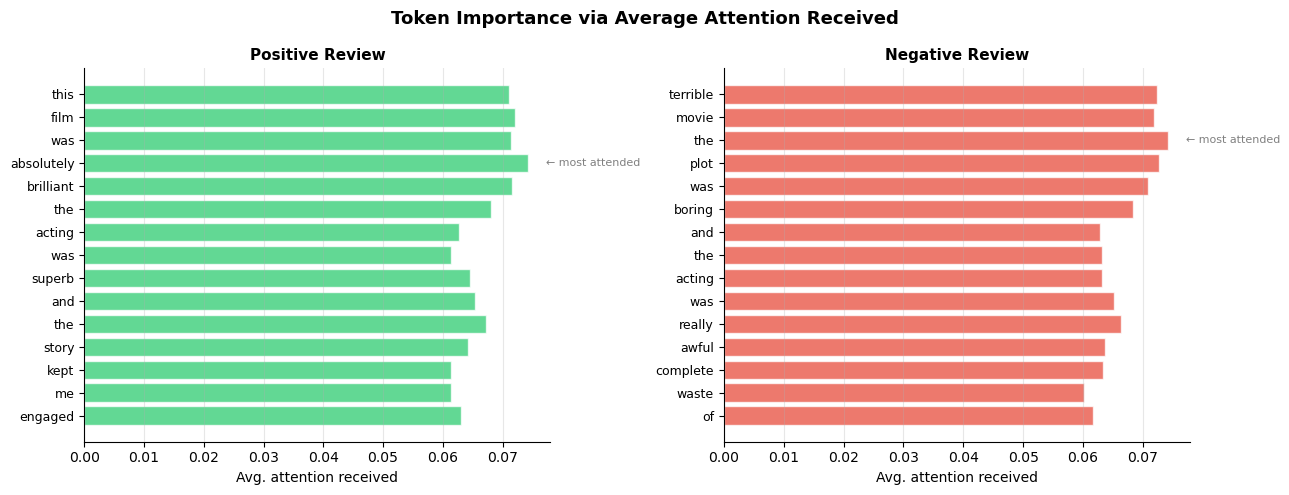

Figure 7 saved.


In [25]:
# Figure 7: Token importance bars (colourblind-friendly)
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Token Importance via Average Attention Received', fontsize=13, fontweight='bold')
colours = ['#2ecc71', '#e74c3c']

for ax, (text, title), colour in zip(axes, reviews, colours):
    tokens = tokenise(text)[:15]
    seq    = review_to_sequence(text)[:len(tokens)]
    _, attn = mha_vis4.forward(seq)
    avg_w  = np.mean([a[:len(tokens), :len(tokens)] for a in attn], axis=0)
    importance = avg_w.mean(axis=0)

    ax.barh(range(len(tokens)), importance, color=colour, alpha=0.75, edgecolor='white')
    ax.set_yticks(range(len(tokens)))
    ax.set_yticklabels(tokens, fontsize=9)
    ax.set_xlabel('Avg. attention received', fontsize=10)
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.invert_yaxis()
    ax.grid(axis='x', alpha=0.3)
    ax.spines[['top', 'right']].set_visible(False)
    top = importance.argmax()
    ax.annotate('← most attended',
                xy=(importance[top], top), xytext=(importance[top] + 0.003, top),
                fontsize=8, color='gray', va='center')

plt.tight_layout()
plt.savefig('fig7_token_importance.png', dpi=130, bbox_inches='tight')
plt.show()
print('Figure 7 saved.')

---
## 7. Key Takeaways

1. **Attention solves the RNN bottleneck** — every token attends directly to every other in one parallel step.
2. **Scaled Dot-Product Attention** computes Q·Kᵀ similarity, scales by √d_k, softmax-normalises, then blends value vectors.
3. **Multi-head attention** runs h parallel heads at reduced dimension — more relational patterns, same compute.
4. **Positional encoding** is essential because attention is order-agnostic.
5. **Attention weights are interpretable** — a rare property in deep learning.

---
## 8. References

1. Vaswani, A. et al. (2017). Attention is all you need. *NeurIPS* 30. https://arxiv.org/abs/1706.03762
2. Alammar, J. (2018). The Illustrated Transformer. https://jalammar.github.io/illustrated-transformer/
3. Devlin, J. et al. (2018). BERT. https://arxiv.org/abs/1810.04805
4. Hugging Face IMDB dataset. https://huggingface.co/datasets/imdb
